# Import

In [1]:
# =============================================================================
# Imports
# =============================================================================
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import time
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import torch
import yaml
from sklearn.decomposition import PCA

# USER CONFIGURATION — edit these to match your environment

In [ ]:
# =============================================================================
# USER CONFIGURATION -- LC_TLS_10x
# =============================================================================

SPACROSS_ROOT = Path(r"/home/dal875013/work/projects/mocha/methods/spacross/SpaCross")

DATA_ROOT = Path(r"/groups/qiwei/mocha/QuickSRT/KLC_TLS_10x/data/L")

OUTPUT_DIR = Path(r"/home/dal875013/work/projects/mocha/results/Spacross/klc_tls_spacross/L")

CONFIG_PATH = SPACROSS_ROOT / "Config" / "DLPFC.yaml"

ALL_LC_TLS_SAMPLES = ["LC1", "LC2", "LC3", "LC4", "LC5"]

SAMPLES_TO_RUN = "all"

METHOD_NAME = "SpaCross"
CLUST_METHOD = "mclust"
NUM_RUNS = 1

# Fixed spatial domains for LC_TLS
NUM_CLUSTERS_LC_TLS = 4

GT_LABEL_COL = "z"
SPATIAL_KEY = "S"


# =============================================================================
# GPU / device setup
# =============================================================================
def get_device():
    if torch.cuda.is_available():
        dev = "cuda:0"
        os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")
        logging.info(f"[DEVICE] CUDA available -- using {dev}")
        logging.info(f"[DEVICE] GPU name: {torch.cuda.get_device_name(0)}")
        logging.info(
            f"[DEVICE] GPU memory: "
            f"{torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB"
        )
    else:
        dev = "cpu"
        logging.warning("[DEVICE] No CUDA GPU -- falling back to CPU")
    return dev


def setup_logging(output_dir: Path):
    output_dir.mkdir(parents=True, exist_ok=True)
    log_file = output_dir / "benchmark.log"
    logging.basicConfig(
        level=logging.INFO,
        format="%(asctime)s [%(levelname)s] %(message)s",
        handlers=[
            logging.StreamHandler(sys.stdout),
            logging.FileHandler(log_file, mode="w", encoding="utf-8"),
        ],
        force=True,
    )
    logging.info(f"Log file: {log_file}")


def resolve_samples(selector) -> list:
    if selector is None or selector == "all":
        return list(ALL_LC_TLS_SAMPLES)
    if isinstance(selector, str):
        return [selector]
    if isinstance(selector, (list, tuple)):
        return [str(s) for s in selector]
    raise ValueError(f"Unrecognized SAMPLES_TO_RUN value: {selector!r}")

In [11]:
# =============================================================================
# Data loading -- LC_TLS-specific
# =============================================================================
def load_lc_tls_sample(config: dict, sample_id: str, tools_mod):
    h5ad_path = DATA_ROOT / f"SCE_{sample_id}.h5ad"
    logging.info(f"  [LOAD] Reading {h5ad_path}")

    if not h5ad_path.exists():
        raise FileNotFoundError(f"Missing .h5ad file: {h5ad_path}")

    adata = sc.read_h5ad(h5ad_path)
    adata.var_names_make_unique()

    logging.info(
        f"  [DIAG] Loaded AnnData: n_obs={adata.n_obs}, n_vars={adata.n_vars}"
    )
    logging.info(f"  [DIAG] obs columns: {list(adata.obs.columns)}")
    logging.info(f"  [DIAG] obsm keys  : {list(adata.obsm.keys())}")

    if GT_LABEL_COL not in adata.obs.columns:
        raise KeyError(
            f"GT_LABEL_COL={GT_LABEL_COL!r} not in adata.obs. "
            f"Available: {list(adata.obs.columns)}"
        )

    adata.obs["layer_guess"] = adata.obs[GT_LABEL_COL].astype(object)

    gt_vals = adata.obs["layer_guess"]
    n_labeled = gt_vals.notna().sum()
    uniq_labels = sorted([str(x) for x in gt_vals.dropna().unique()])

    logging.info(
        f"  [DIAG] Using GT column '{GT_LABEL_COL}' "
        f"(labeled: {n_labeled}/{adata.n_obs}, classes: {uniq_labels})"
    )

    if "spatial" not in adata.obsm:
        if SPATIAL_KEY in adata.obsm:
            adata.obsm["spatial"] = np.asarray(adata.obsm[SPATIAL_KEY])
            logging.info(
                f"  [DIAG] Aliased obsm['{SPATIAL_KEY}'] -> obsm['spatial']"
            )
        else:
            raise KeyError(
                f"No spatial coordinates in {h5ad_path}. "
                f"Available obsm: {list(adata.obsm.keys())}"
            )

    logging.info(f"  [DIAG] spatial coords shape: {adata.obsm['spatial'].shape}")

    k = config["data"]["k_cutoff"]
    edge_index = tools_mod.graph_construction(adata, k)

    logging.info(f"  [DIAG] Built k-NN graph (k={k})")
    if isinstance(edge_index, torch.Tensor):
        logging.info(f"  [DIAG] graph shape: {tuple(edge_index.shape)}")
        logging.info(f"  [DIAG] graph is_sparse: {edge_index.is_sparse}")

    if hasattr(adata.X, "toarray"):
        adata.layers["count"] = adata.X.toarray()
    else:
        adata.layers["count"] = np.asarray(adata.X).copy()

    sc.pp.filter_genes(adata, min_cells=50)
    sc.pp.filter_genes(adata, min_counts=10)
    logging.info(f"  [DIAG] After gene filter: n_vars={adata.n_vars}")

    sc.pp.normalize_total(adata, target_sum=1e6)

    top_g = min(config["data"]["top_genes"], adata.n_vars)
    sc.pp.highly_variable_genes(
        adata,
        flavor="seurat_v3",
        layer="count",
        n_top_genes=top_g,
    )

    adata = adata[:, adata.var["highly_variable"]].copy()
    sc.pp.scale(adata)

    logging.info(
        f"  [DIAG] After HVG selection: n_vars={adata.n_vars} (target={top_g})"
    )

    n_pcs = min(200, adata.n_vars, adata.n_obs - 1)
    adata.obsm["X_pca"] = PCA(
        n_components=n_pcs,
        random_state=42,
    ).fit_transform(adata.X)

    logging.info(f"  [DIAG] PCA done: X_pca shape={adata.obsm['X_pca'].shape}")

    return adata, edge_index

In [12]:
# =============================================================================
# Training + metrics for one sample
# =============================================================================
def train_one_sample(
    sample_id: str,
    adata,
    edge_index,
    config: dict,
    device: str,
    tools_mod,
    clust_method: str = "mclust",
    run_seed: int = 0,
):
    num_clusters = NUM_CLUSTERS_LC_TLS

    logging.info(
        f"  [TRAIN] Starting SpaCross | sample={sample_id} | "
        f"k_clusters={num_clusters} | device={device} | run_seed={run_seed}"
    )

    t0 = time.time()

    net = tools_mod.SC_pipeline(
        adata,
        edge_index=edge_index,
        num_clusters=num_clusters,
        device=device,
        config=config,
        roundseed=run_seed,
        imputation=False,
    )

    net.trian()
    enc_rep, recon = net.process()

    adata.obsm["latent"] = enc_rep
    adata.obsm["recon"] = recon

    logging.info(
        f"  [DIAG] Latent shape: {enc_rep.shape}  Recon shape: {recon.shape}"
    )

    pred_labels = tools_mod.clustering(
        z=enc_rep,
        n_clust=num_clusters,
        num_seed=1,
        method=clust_method,
    )

    adata.obs[clust_method] = pred_labels

    logging.info(
        f"  [DIAG] Cluster sizes: "
        f"{pd.Series(pred_labels).astype(str).value_counts().to_dict()}"
    )

    elapsed = time.time() - t0

    sub_adata = adata[~pd.isnull(adata.obs["layer_guess"])]

    ARI, ACC, DIS = tools_mod.get_metrics(
        sub_adata,
        "layer_guess",
        clust_method,
    )

    from SpaCross.Utils import compute_NMI
    NMI = compute_NMI(sub_adata, "layer_guess", clust_method)

    gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"

    metrics = {
        "method": METHOD_NAME,
        "dataset": "LC_TLS_10x",
        "sample": sample_id,
        "run_seed": run_seed,
        "ARI": float(ARI),
        "NMI": float(NMI),
        "ACC": float(ACC),
        "DIS": float(DIS),
        "running_time_sec": round(elapsed, 2),
        "gpu_model": gpu_name,
        "num_clusters": int(num_clusters),
        "num_spots": int(adata.n_obs),
        "num_labeled_spots": int(sub_adata.n_obs),
        "num_genes_after_hvg": int(adata.n_vars),
        "clust_method": clust_method,
        "device": device,
    }

    logging.info(
        f"  [METRICS] ARI={ARI:.4f}  NMI={NMI:.4f}  ACC={ACC:.4f}  "
        f"DIS={DIS:.4f}  time={elapsed:.1f}s  gpu={gpu_name}"
    )

    pred_df = pd.DataFrame({
        "method": METHOD_NAME,
        "dataset": "LC_TLS_10x",
        "sample": sample_id,
        "run_seed": run_seed,
        "spot_id": adata.obs_names.astype(str).to_numpy(),
        "true_label": adata.obs["layer_guess"].astype(object).to_numpy(),
        "pred_label": np.asarray(adata.obs[clust_method]).astype(str),
    })

    return metrics, pred_df

# Main benchmark loop

In [13]:
# =============================================================================
# Main benchmark loop
# =============================================================================
def run_benchmark():
    setup_logging(OUTPUT_DIR)

    logging.info("=" * 72)
    logging.info("SpaCross LC_TLS_10x Benchmarking Framework")
    logging.info("=" * 72)

    if not SPACROSS_ROOT.exists():
        raise FileNotFoundError(
            f"SPACROSS_ROOT not found: {SPACROSS_ROOT.resolve()}"
        )

    sys.path.insert(0, str(SPACROSS_ROOT.resolve()))
    import SpaCross as TOOLS

    device = get_device()

    if not DATA_ROOT.exists():
        raise FileNotFoundError(f"DATA_ROOT not found: {DATA_ROOT.resolve()}")

    logging.info(f"[PATHS] SPACROSS_ROOT = {SPACROSS_ROOT.resolve()}")
    logging.info(f"[PATHS] DATA_ROOT     = {DATA_ROOT.resolve()}")
    logging.info(f"[PATHS] OUTPUT_DIR    = {OUTPUT_DIR.resolve()}")
    logging.info(f"[PATHS] CONFIG_PATH   = {CONFIG_PATH.resolve()}")

    with open(CONFIG_PATH, "r", encoding="utf-8") as f:
        config = yaml.safe_load(f)

    config["data"]["dataset"] = "LC_TLS_10x"

    logging.info(f"[CONFIG] {config}")

    samples = resolve_samples(SAMPLES_TO_RUN)

    logging.info(f"[SAMPLES] Will process {len(samples)} sample(s): {samples}")
    logging.info(
        f"[SETTINGS] clust_method={CLUST_METHOD}  "
        f"num_runs={NUM_RUNS}  num_clusters={NUM_CLUSTERS_LC_TLS}"
    )

    all_metrics = []
    all_predictions = []
    failed = []

    for i, sample_id in enumerate(samples, start=1):
        logging.info("")
        logging.info("-" * 72)
        logging.info(f"[{i}/{len(samples)}] Sample {sample_id}")
        logging.info("-" * 72)

        try:
            adata, edge_index = load_lc_tls_sample(config, sample_id, TOOLS)

            for run in range(NUM_RUNS):
                logging.info(f"  -> Run {run + 1}/{NUM_RUNS}")

                adata_run = adata.copy()

                metrics, pred_df = train_one_sample(
                    sample_id=sample_id,
                    adata=adata_run,
                    edge_index=edge_index,
                    config=config,
                    device=device,
                    tools_mod=TOOLS,
                    clust_method=CLUST_METHOD,
                    run_seed=run,
                )

                all_metrics.append(metrics)
                all_predictions.append(pred_df)

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        except Exception as e:
            logging.exception(f"[FAILED] Sample {sample_id}: {e}")
            failed.append({"sample": sample_id, "error": str(e)})

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

            continue

    if not all_metrics:
        logging.error("No successful runs -- nothing to save.")
        return

    predictions = pd.concat(all_predictions, ignore_index=True)
    performance = pd.DataFrame(all_metrics)

    perf_lead = [
        "method", "dataset", "sample", "run_seed",
        "ARI", "NMI", "ACC", "DIS",
        "running_time_sec", "gpu_model",
    ]

    performance = performance[
        perf_lead + [c for c in performance.columns if c not in perf_lead]
    ]

    pred_lead = [
        "method", "dataset", "sample", "run_seed",
        "spot_id", "true_label", "pred_label",
    ]

    predictions = predictions[pred_lead]

    pred_path = OUTPUT_DIR / "predictions.parquet"
    perf_path = OUTPUT_DIR / "performance.parquet"

    predictions.to_parquet(pred_path, index=False)
    performance.to_parquet(perf_path, index=False)

    logging.info("")
    logging.info("=" * 72)
    logging.info("SAVED")
    logging.info("=" * 72)

    logging.info(
        f"  predictions.parquet -> {pred_path}  ({len(predictions):,} rows)"
    )
    logging.info(
        f"  performance.parquet -> {perf_path}  ({len(performance):,} rows)"
    )

    logging.info("")
    logging.info("Per-sample metrics:")
    logging.info(
        "\n" + performance[
            ["sample", "ARI", "NMI", "ACC", "DIS", "running_time_sec"]
        ].to_string(index=False)
    )

    logging.info("")
    logging.info(
        f"Overall mean ARI: {performance['ARI'].mean():.4f}  "
        f"NMI: {performance['NMI'].mean():.4f}  "
        f"ACC: {performance['ACC'].mean():.4f}  "
        f"DIS: {performance['DIS'].mean():.4f}"
    )

    if failed:
        logging.warning(f"\n{len(failed)} sample(s) failed:")
        for f_ in failed:
            logging.warning(f"  - {f_['sample']}: {f_['error']}")

    logging.info("\nBenchmarking complete.")


if __name__ == "__main__":
    run_benchmark()

2026-05-11 12:13:08,641 [INFO] Log file: /home/dal875013/work/projects/mocha/results/klc_tls_spacross/L/benchmark.log
2026-05-11 12:13:08,642 [INFO] ========================================================================
2026-05-11 12:13:08,643 [INFO] SpaCross LC_TLS_10x Benchmarking Framework
2026-05-11 12:13:08,643 [INFO] ========================================================================
2026-05-11 12:13:08,648 [INFO] [DEVICE] CUDA available -- using cuda:0
2026-05-11 12:13:08,649 [INFO] [DEVICE] GPU name: NVIDIA A30
2026-05-11 12:13:08,649 [INFO] [DEVICE] GPU memory: 25.22 GB
2026-05-11 12:13:08,654 [INFO] [PATHS] SPACROSS_ROOT = /work/dal875013/projects/mocha/methods/spacross/SpaCross
2026-05-11 12:13:08,656 [INFO] [PATHS] DATA_ROOT     = /groups/qiwei/mocha/QuickSRT/KLC_TLS_10x/data/L
2026-05-11 12:13:08,658 [INFO] [PATHS] OUTPUT_DIR    = /work/dal875013/projects/mocha/results/klc_tls_spacross/L
2026-05-11 12:13:08,661 [INFO] [PATHS] CONFIG_PATH   = /work/dal875013/projects

Epoch 299 total loss=1.599 recon loss=1.109 mean loss=0.397 tri loss=1.357: 100%|██████████| 300/300 [00:09<00:00, 33.28it/s]

2026-05-11 12:13:21,584 [INFO]   [DIAG] Latent shape: (4361, 16)  Recon shape: (4361, 200)


[DEBUG mclust] emb shape = (4361, 16), dtype = float64
fitting ...
  |======================================================================| 100%
2026-05-11 12:13:26,447 [INFO]   [DIAG] Cluster sizes: {'2': 2364, '3': 1140, '1': 818, '4': 39}
2026-05-11 12:13:26,993 [INFO]   [METRICS] ARI=0.0539  NMI=0.1833  ACC=0.1837  DIS=0.0381  time=13.9s  gpu=NVIDIA A30
2026-05-11 12:13:26,998 [INFO] 
2026-05-11 12:13:26,999 [INFO] ------------------------------------------------------------------------
2026-05-11 12:13:26,999 [INFO] [2/5] Sample LC2
2026-05-11 12:13:27,000 [INFO] ------------------------------------------------------------------------
2026-05-11 12:13:27,001 [INFO]   [LOAD] Reading /groups/qiwei/mocha/QuickSRT/KLC_TLS_10x/data/L/SCE_LC2.h5ad
2026-05-11 12:13:27,084 [INFO]   [DIAG] Loaded AnnData: n_obs=2935, n_vars=17845
2026-05-11 12:13:27,088 [INFO]   [DIAG] obs columns: ['z']
2026-05-11 12:13:27,088 [INFO]   [DIAG] obsm keys  : ['S']
2026-05-11 12:13:27,090 [INFO]   [DIAG] Us

Epoch 299 total loss=1.445 recon loss=0.825 mean loss=0.422 tri loss=1.373: 100%|██████████| 300/300 [00:06<00:00, 43.08it/s]


...

2026-05-11 12:14:07,871 [INFO]   [DIAG] Latent shape: (2939, 16)  Recon shape: (2939, 200)


[DEBUG mclust] emb shape = (2939, 16), dtype = float64
fitting ...
  |======================================================================| 100%
2026-05-11 12:14:12,576 [INFO]   [DIAG] Cluster sizes: {'2': 1136, '1': 734, '4': 671, '3': 398}
2026-05-11 12:14:12,675 [INFO]   [METRICS] ARI=0.0564  NMI=0.1613  ACC=0.1615  DIS=0.0396  time=12.2s  gpu=NVIDIA A30
2026-05-11 12:14:12,679 [INFO] 
2026-05-11 12:14:12,680 [INFO] ------------------------------------------------------------------------
2026-05-11 12:14:12,681 [INFO] [5/5] Sample LC5
2026-05-11 12:14:12,681 [INFO] ------------------------------------------------------------------------
2026-05-11 12:14:12,682 [INFO]   [LOAD] Reading /groups/qiwei/mocha/QuickSRT/KLC_TLS_10x/data/L/SCE_LC5.h5ad
2026-05-11 12:14:12,731 [INFO]   [DIAG] Loaded AnnData: n_obs=2017, n_vars=17845
2026-05-11 12:14:12,732 [INFO]   [DIAG] obs columns: ['z']
2026-05-11 12:14:12,733 [INFO]   [DIAG] obsm keys  : ['S']
2026-05-11 12:14:12,734 [INFO]   [DIAG] Us

Epoch 299 total loss=1.403 recon loss=0.767 mean loss=0.409 tri loss=1.367: 100%|██████████| 300/300 [00:06<00:00, 45.59it/s]

2026-05-11 12:14:20,958 [INFO]   [DIAG] Latent shape: (2017, 16)  Recon shape: (2017, 200)


[DEBUG mclust] emb shape = (2017, 16), dtype = float64
fitting ...
  |======================================================================| 100%
2026-05-11 12:14:25,146 [INFO]   [DIAG] Cluster sizes: {'1': 1177, '3': 413, '2': 387, '4': 40}
2026-05-11 12:14:25,201 [INFO]   [METRICS] ARI=0.5716  NMI=0.6220  ACC=0.6226  DIS=0.0475  time=10.8s  gpu=NVIDIA A30
2026-05-11 12:14:25,244 [INFO] 
2026-05-11 12:14:25,245 [INFO] ========================================================================
2026-05-11 12:14:25,246 [INFO] SAVED
2026-05-11 12:14:25,246 [INFO] ========================================================================
2026-05-11 12:14:25,247 [INFO]   predictions.parquet -> /home/dal875013/work/projects/mocha/results/klc_tls_spacross/L/predictions.parquet  (16,032 rows)
2026-05-11 12:14:25,248 [INFO]   performance.parquet -> /home/dal875013/work/projects/mocha/results/klc_tls_spacross/L/performance.parquet  (5 rows)
2026-05-11 12:14:25,248 [INFO] 
2026-05-11 12:14:25,249 [IN

... storing 'true_label' as categorical
... storing 'pred_label' as categorical


SAMPLE_ID = LC3
n spots in adata      : 3780
n predictions matched : 3780


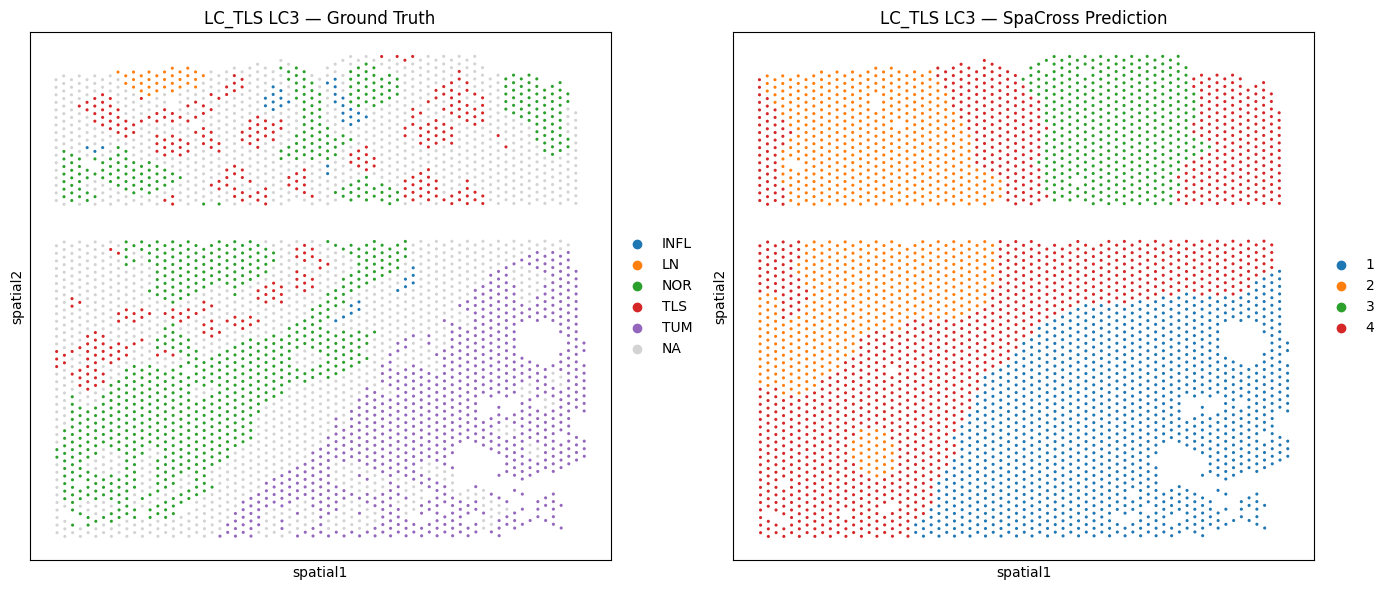

In [ ]:
# prediction results visualization

import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
from pathlib import Path

DATA_ROOT  = Path(r"/groups/qiwei/mocha/QuickSRT/KLC_TLS_10x/data/L")
OUTPUT_DIR = Path(r"/home/dal875013/work/projects/mocha/results/Spacross/klc_tls_spacross/L")

SAMPLE_ID = "LC3"   # change to "LC2", "LC3", "LC4", or "LC5"

predictions = pd.read_parquet(OUTPUT_DIR / "predictions.parquet")

predictions["sample"] = predictions["sample"].astype(str)
pred_slice = predictions[predictions["sample"] == str(SAMPLE_ID)].copy()

if pred_slice.empty:
    available = sorted(predictions["sample"].unique())
    raise ValueError(
        f"No predictions found for sample {SAMPLE_ID}. "
        f"Available samples: {available}"
    )

pred_slice = pred_slice.set_index("spot_id")

adata = sc.read_h5ad(DATA_ROOT / f"SCE_{SAMPLE_ID}.h5ad")
adata.var_names_make_unique()

adata.obs["true_label"] = pred_slice["true_label"].reindex(adata.obs_names).values
adata.obs["pred_label"] = pred_slice["pred_label"].reindex(adata.obs_names).values

if "spatial" not in adata.obsm:
    if "S" in adata.obsm:
        adata.obsm["spatial"] = np.asarray(adata.obsm["S"])
    else:
        raise KeyError(f"No spatial coordinates found. obsm keys = {list(adata.obsm.keys())}")

print(f"SAMPLE_ID = {SAMPLE_ID}")
print(f"n spots in adata      : {adata.n_obs}")
print(f"n predictions matched : {pred_slice.index.isin(adata.obs_names).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc.pl.embedding(
    adata,
    basis="spatial",
    color="true_label",
    ax=axes[0],
    show=False,
    title=f"LC_TLS {SAMPLE_ID} — Ground Truth",
    s=20,
)

sc.pl.embedding(
    adata,
    basis="spatial",
    color="pred_label",
    ax=axes[1],
    show=False,
    title=f"LC_TLS {SAMPLE_ID} — SpaCross Prediction",
    s=20,
)

axes[0].invert_yaxis()
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# Running results summary

import pandas as pd
from pathlib import Path

OUTPUT_DIR = Path(r"/home/dal875013/work/projects/mocha/results/Spacross/klc_tls_spacross/L")

perf_path = OUTPUT_DIR / "performance.parquet"

if not perf_path.exists():
    raise FileNotFoundError(f"Cannot find {perf_path}")

performance = pd.read_parquet(perf_path)

performance["sample"] = performance["sample"].astype(str)
performance = performance.sort_values(["sample", "run_seed"]).reset_index(drop=True)

display_cols = [
    "dataset", "sample", "run_seed",
    "ARI", "NMI", "ACC", "DIS",
    "num_clusters", "num_spots", "num_labeled_spots",
    "running_time_sec", "clust_method", "gpu_model",
]

display_cols = [c for c in display_cols if c in performance.columns]

print("===== All LC_TLS SpaCross results =====")
display(performance[display_cols])

print("\n===== Summary =====")
summary_cols = [c for c in ["ARI", "NMI", "ACC", "DIS", "running_time_sec"] if c in performance.columns]
display(performance[summary_cols].describe())

print("\n===== Mean metrics =====")
print(f"Mean ARI: {performance['ARI'].mean():.4f}")
print(f"Mean NMI: {performance['NMI'].mean():.4f}")
print(f"Mean ACC: {performance['ACC'].mean():.4f}")
print(f"Mean DIS: {performance['DIS'].mean():.4f}")

print("\n===== Best / worst ARI =====")
best = performance.loc[performance["ARI"].idxmax()]
worst = performance.loc[performance["ARI"].idxmin()]

print(f"Best ARI : {best['sample']}  ARI={best['ARI']:.4f}")
print(f"Worst ARI: {worst['sample']}  ARI={worst['ARI']:.4f}")

===== All LC_TLS SpaCross results =====


,dataset,sample,run_seed,ARI,NMI,ACC,DIS,num_clusters,num_spots,num_labeled_spots,running_time_sec,clust_method,gpu_model
0,LC_TLS_10x,LC1,0,0.053892,0.183268,0.183657,0.038087,4,4361,2475,13.90,mclust,NVIDIA A30
1,LC_TLS_10x,LC2,0,0.452090,0.481813,0.481861,0.046783,4,2935,1122,11.41,mclust,NVIDIA A30
2,LC_TLS_10x,LC3,0,0.543799,0.500146,0.500646,0.036874,4,3780,2120,12.98,mclust,NVIDIA A30
3,LC_TLS_10x,LC4,0,0.056408,0.161259,0.161455,0.039596,4,2939,937,12.17,mclust,NVIDIA A30
4,LC_TLS_10x,LC5,0,0.571642,0.621986,0.622623,0.047457,4,2017,622,10.79,mclust,NVIDIA A30



===== Summary =====


,ARI,NMI,ACC,DIS,running_time_sec
count,5.000000,5.000000,5.000000,5.000000,5.000000
mean,0.335566,0.389695,0.390048,0.041759,12.250000
std,0.259779,0.205815,0.205915,0.004993,1.234808
min,0.053892,0.161259,0.161455,0.036874,10.790000
25%,0.056408,0.183268,0.183657,0.038087,11.410000
50%,0.452090,0.481813,0.481861,0.039596,12.170000
75%,0.543799,0.500146,0.500646,0.046783,12.980000
max,0.571642,0.621986,0.622623,0.047457,13.900000



===== Mean metrics =====
Mean ARI: 0.3356
Mean NMI: 0.3897
Mean ACC: 0.3900
Mean DIS: 0.0418

===== Best / worst ARI =====
Best ARI : LC5  ARI=0.5716
Worst ARI: LC1  ARI=0.0539


In [ ]:
# actual layer in ground truth checking

import scanpy as sc
import pandas as pd
from pathlib import Path

DATA_ROOT = Path("/groups/qiwei/mocha/QuickSRT/KLC_TLS_10x/data/L")

ALL_LC_TLS_SAMPLES = [
    "LC1",
    "LC2",
    "LC3",
    "LC4",
    "LC5",
]

results = []

for sample_id in ALL_LC_TLS_SAMPLES:
    path = DATA_ROOT / f"SCE_{sample_id}.h5ad"

    if not path.exists():
        print(f"[MISSING] {sample_id}")
        continue

    adata = sc.read_h5ad(path)

    if "z" not in adata.obs:
        print(f"[NO LABEL] {sample_id}")
        continue

    labels_all = adata.obs["z"]

    # remove NaN labels
    labels = labels_all.dropna()

    unique_labels = sorted(labels.unique())
    n_classes = len(unique_labels)

    results.append({
        "sample": sample_id,
        "n_classes": n_classes,
        "labels": unique_labels,
        "n_spots": adata.n_obs,
        "n_labeled": len(labels),
        "n_NA": int(labels_all.isna().sum()),
    })

df = pd.DataFrame(results).sort_values("n_classes")

print("===== LC_TLS_10x: Per-sample class counts =====")
display(df)

print("\n===== Summary =====")
print(df["n_classes"].value_counts().sort_index())

print("\n===== Samples with only 1 class =====")
print(df[df["n_classes"] == 1]["sample"].tolist())

print("\n===== Suggested dictionary: sample -> n_classes =====")
cluster_dict = dict(zip(df["sample"], df["n_classes"]))
print(cluster_dict)
print(cluster_dict)

===== LC_TLS_10x: Per-sample class counts =====


,sample,n_classes,labels,n_spots,n_labeled,n_NA
0,LC1,4,"[INFL, NOR, TLS, TUM]",4361,2475,1886
1,LC2,4,"[INFL, NOR, TLS, TUM]",2935,1122,1813
3,LC4,4,"[INFL, NOR, TLS, TUM]",2939,937,2002
4,LC5,4,"[INFL, NOR, TLS, TUM]",2017,622,1395
2,LC3,5,"[INFL, LN, NOR, TLS, TUM]",3780,2120,1660



===== Summary =====
n_classes
4    4
5    1
Name: count, dtype: int64

===== Samples with only 1 class =====
[]

===== Suggested dictionary: sample -> n_classes =====
{'LC1': 4, 'LC2': 4, 'LC4': 4, 'LC5': 4, 'LC3': 5}
{'LC1': 4, 'LC2': 4, 'LC4': 4, 'LC5': 4, 'LC3': 5}
